In [32]:


import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)



In [33]:
# Importing the libraries necessary for the exercise.
import warnings
import pandas as pd
import numpy as np



In [34]:
# Reading dataset
df = pd.read_csv("/content/diabetes.csv")

# Looking at the first 5 rows of the data set
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
# Getting general information about the data set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## EDA

In [37]:
# Looking at the descriptive statistics of the data set
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


You can see the describe () function of our data set above. In this table, "min" shows the smallest number in that variable.

We see that the smallest values of Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin and BMI variables are 0. Except for the Pregnancies variable, there is no possibility that any of these variables are 0.

Not all 0 values in the "Pima Indians Diabetes Database" are actually 0. Empty values are also filled with 0.

In [38]:
# Before solving this problem, let's check the null values.
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [39]:
# We can solve this problem by assigning NaN to 0 values in variables that we think are errors.
df[["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]] = \
    df[["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]].replace(0, np.nan)

In [40]:
# Now let's see how many rows we have assigned NaN instead of 0.
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [41]:
# With this function, we were able to separate the variables in the data set as categorical and numerical.
def grab_col_names(dataframe, cat_th=10, car_th=20):
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]

    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                   dataframe[col].dtypes != "O"]

    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and
                   dataframe[col].dtypes == "O"]

    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f'cat_cols: {len(cat_cols)}')
    print(f'num_cols: {len(num_cols)}')
    print(f'cat_but_car: {len(cat_but_car)}')
    print(f'num_but_cat: {len(num_but_cat)}')

    return cat_cols, cat_but_car, num_cols, num_but_cat


In [42]:
cat_cols, cat_but_car, num_cols, num_but_cat = grab_col_names(df)

cat_cols: 1
num_cols: 8
cat_but_car: 0
num_but_cat: 1


## Outliers

In [43]:
# Setting an upper and lower limit for outliers
def outlier_thresholds(dataframe, variable):
    quartile1 = dataframe[variable].quantile(0.25)
    quartile3 = dataframe[variable].quantile(0.75)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit

In [44]:
# The function that examines whether there is an outlier according to the threshold values we have determined.
def check_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    if dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None):
        return True
    else:
        return False

In [45]:
for col in num_cols:
    print(col, check_outlier(df, col))

Pregnancies True
Glucose False
BloodPressure True
SkinThickness True
Insulin True
BMI True
DiabetesPedigreeFunction True
Age True


In [46]:
# Replacing outliers with upper and lower limit
def replace_with_thresholds(dataframe, variable):
    low_limit, up_limit = outlier_thresholds(dataframe, variable)
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit

In [47]:
for col in num_cols:
        replace_with_thresholds(df, col)

/tmp/ipykernel_4108/3578424135.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '13.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit
/tmp/ipykernel_4108/3578424135.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '66.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit


## Missing Values


In [48]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [49]:
df.pivot_table(df, index=["Outcome"])

,Age,BMI,BloodPressure,DiabetesPedigreeFunction,Glucose,Insulin,Pregnancies,SkinThickness
Outcome,,,,,,,,
0,31.135000,30.841141,70.810811,0.420264,110.643863,125.186553,3.298000,27.227147
1,37.052239,35.262406,75.210317,0.531022,142.319549,189.782692,4.843284,32.733333


When the variables are examined according to Outcome's being 1 and 0, it is seen that there are differences. When filling the blank values, they should be filled in consideration of this situation.

In [50]:
for col in df.columns:
    df.loc[(df["Outcome"] == 0) & (df[col].isnull()), col] = df[df["Outcome"] == 0][col].median()
    df.loc[(df["Outcome"] == 1) & (df[col].isnull()), col] = df[df["Outcome"] == 1][col].median()

## Feature Engineering

In [51]:

df.loc[(df["BMI"] < 18.5), "NEW_BMI_CAT"] = "Underweight"
df.loc[(df["BMI"] > 18.5) & (df["BMI"] < 25), "NEW_BMI_CAT"] = "Normal"
df.loc[(df["BMI"] > 25) & (df["BMI"] < 30), "NEW_BMI_CAT"] = "Overweight"
df.loc[(df["BMI"] > 30) & (df["BMI"] < 40), "NEW_BMI_CAT"] = "Obese"

df.loc[(df["Glucose"] < 70), "NEW_GLUCOSE_CAT"] = "Low"
df.loc[(df["Glucose"] > 70) & (df["Glucose"] < 99), "NEW_GLUCOSE_CAT"] = "Normal"
df.loc[(df["Glucose"] > 99) & (df["Glucose"] < 126), "NEW_GLUCOSE_CAT"] = "Secret"
df.loc[(df["Glucose"] > 126) & (df["Glucose"] < 200), "NEW_GLUCOSE_CAT"] = "High"

df.loc[df['SkinThickness'] < 30, "NEW_SKIN_THICKNESS"] = "Normal"
df.loc[df['SkinThickness'] >= 30, "NEW_SKIN_THICKNESS"] = "HighFat"

df.loc[df['Pregnancies'] == 0, "NEW_PREGNANCIES"] = "NoPregnancy"
df.loc[((df['Pregnancies'] > 0) & (df['Pregnancies'] <= 4)), "NEW_PREGNANCIES"] = "StdPregnancy"
df.loc[(df['Pregnancies'] > 4), "NEW_PREGNANCIES"] = "OverPregnancy"

df.loc[(df['SkinThickness'] < 30) & (df['BloodPressure'] < 80), "NEW_CIRCULATION_LEVEL"] = "Normal"
df.loc[(df['SkinThickness'] >= 30) & (df['BloodPressure'] >= 80), "NEW_CIRCULATION_LEVEL"] = "CircularAtHighRisk"
df.loc[((df['SkinThickness'] < 30) & (df['BloodPressure'] >= 80))
       | ((df['SkinThickness'] >= 30) & (df['BloodPressure'] < 80)), "NEW_CIRCULATION_LEVEL"] = "CircularAtMediumRisk"

df["Pre_Age_Cat"] = df["Age"] * df["Pregnancies"]

df["Ins_Glu_Cat"] = df["Glucose"] * df["Insulin"]

## Label Encoding

In [52]:
def label_encoder(dataframe, binary_col):
    labelencoder = preprocessing.LabelEncoder()
    dataframe[binary_col] = labelencoder.fit_transform(dataframe[binary_col])
    return dataframe

In [53]:
binary_cols = [col for col in df.columns if df[col].dtypes == "O"
               and len(df[col].unique()) == 2]

In [54]:
from sklearn import preprocessing

for col in df.columns:
    label_encoder(df, col)

## One-Hot Encoding

In [55]:
def one_hot_encoder(dataframe, categorical_cols, drop_first=False):
    dataframe = pd.get_dummies(dataframe, columns=categorical_cols, drop_first=drop_first)
    return dataframe

In [56]:
ohe_cols = [col for col in df.columns if 10 >= len(df[col].unique()) > 2]

In [57]:
one_hot_encoder(df, ohe_cols, drop_first=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,NEW_SKIN_THICKNESS,...,NEW_BMI_CAT_3,NEW_BMI_CAT_4,NEW_GLUCOSE_CAT_1,NEW_GLUCOSE_CAT_2,NEW_GLUCOSE_CAT_3,NEW_GLUCOSE_CAT_4,NEW_PREGNANCIES_1,NEW_PREGNANCIES_2,NEW_CIRCULATION_LEVEL_1,NEW_CIRCULATION_LEVEL_2
0,6,85,21,27,103,122,350,29,1,0,...,False,False,False,False,False,False,True,False,True,False
1,1,22,18,21,66,61,196,10,0,1,...,False,False,False,True,False,False,False,True,False,True
2,8,120,16,24,103,29,368,11,1,0,...,False,False,False,False,False,False,True,False,True,False
3,1,26,18,15,61,76,53,0,0,1,...,False,False,False,True,False,False,False,True,False,True
4,0,74,3,27,102,208,489,12,1,0,...,False,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,10,38,25,40,109,117,55,42,0,0,...,False,False,False,False,True,False,True,False,True,False
764,2,59,20,19,66,154,187,6,0,1,...,False,False,False,False,True,False,False,True,False,True
765,5,58,21,15,71,57,115,9,0,1,...,False,False,False,False,True,False,True,False,False,True
766,1,63,13,24,103,94,195,26,1,0,...,False,False,False,False,False,True,False,True,True,False


## Model

In [58]:
from sklearn.model_selection import train_test_split
y = df["Outcome"]
X = df.drop(["Outcome"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=17)

In [59]:
pip install numpy pandas keras scikit-learn


In [60]:
from keras.src.utils.numerical_utils import to_categorical
from keras.models import Sequential, Input
from keras.layers import Dense,Activation,BatchNormalization
from keras.utils import to_categorical

In [ ]:
from keras.optimizers import Adam

In [63]:
y_train = to_categorical(y_train, num_classes=2)
y_Test = to_categorical(y_test, num_classes=2)

In [64]:
y_train[0]

array([1., 0.])

In [67]:
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(500, activation="relu"))
model.add(BatchNormalization())
model.add(Dense(250, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(2,activation="softmax"))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [68]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Recompile the model with Adam optimizer
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

In [69]:
# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7366 - loss: 0.7295 - val_accuracy: 0.3241 - val_loss: 5.7528
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8368 - loss: 0.4423 - val_accuracy: 0.4074 - val_loss: 2.9578
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8625 - loss: 0.3697 - val_accuracy: 0.6019 - val_loss: 1.1972
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8625 - loss: 0.3390 - val_accuracy: 0.6019 - val_loss: 1.1189
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8718 - loss: 0.2905 - val_accuracy: 0.6481 - val_loss: 0.8328
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8625 - loss: 0.3052 - val_accuracy: 0.6574 - val_loss: 0.8142
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8741 - loss: 0.2899 - val_accuracy: 0.7685 - val_loss: 0.6692
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8765 - loss: 0.2958 - val_accuracy: 0.76

In [70]:
loss, accuracy = model.evaluate(X_test, y_Test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8528 - loss: 0.7187 
Test Loss: 0.7187
Test Accuracy: 0.8528


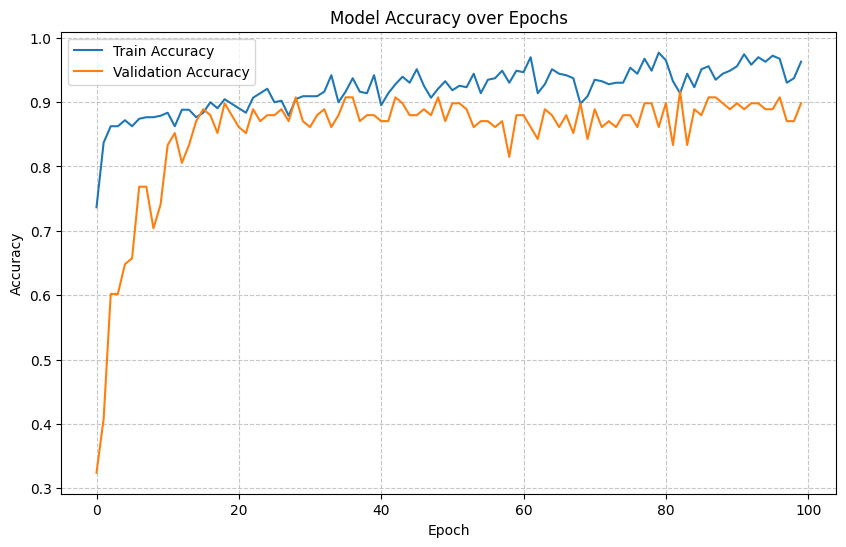

In [71]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [72]:
model.compile(loss="categorical_crossentropy",optimizer="adam",metrics=["accuracy"])

In [76]:
model.fit(X_train, y_train, validation_data=(X_test, y_Test), epochs=20, batch_size=20, verbose=1)

Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9106 - loss: 0.2521 - val_accuracy: 0.7835 - val_loss: 0.8502
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8994 - loss: 0.2383 - val_accuracy: 0.8571 - val_loss: 0.6356
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9255 - loss: 0.1955 - val_accuracy: 0.8355 - val_loss: 0.5700
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8976 - loss: 0.2212 - val_accuracy: 0.8398 - val_loss: 0.5418
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8994 - loss: 0.2382 - val_accuracy: 0.8355 - val_loss: 0.5683
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9143 - loss: 0.1901 - val_accuracy: 0.8528 - val_loss: 0.5273
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9162 - loss: 0.2084 - val_accuracy: 0.8485 - val_loss: 0.4904
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9218 - loss: 0.1836 - val_accuracy: 0.8615 - val_loss

### Comparing different Optimizers

In [80]:
from keras.optimizers import SGD, RMSprop, Adam
from keras.losses import CategoricalCrossentropy, BinaryCrossentropy, Hinge
import time
import numpy as np

optimizers = {
    "Adam": Adam, # Store the class, not an instance
    "SGD": SGD,   # Store the class, not an instance
    "RMSprop": RMSprop # Store the class, not an instance
}

loss_functions = {
    "CategoricalCrossentropy": CategoricalCrossentropy(),
    "BinaryCrossentropy": BinaryCrossentropy(),
    "Hinge": Hinge()
}

results = []

# Prepare target variables for different loss functions
# Original y_train, y_Test are one-hot encoded (e.g., [1., 0.] or [0., 1.])
y_train_binary_labels = np.argmax(y_train, axis=1) # Converts to 0 or 1
y_test_binary_labels = np.argmax(y_Test, axis=1)   # Converts to 0 or 1

y_train_hinge_labels = 2 * y_train_binary_labels - 1 # Converts to -1 or 1
y_test_hinge_labels = 2 * y_test_binary_labels - 1   # Converts to -1 or 1

for loss_name, loss_func in loss_functions.items():
    for opt_name, optimizer_class in optimizers.items(): # Iterate over optimizer classes
        print(f"\nTraining with Loss: {loss_name}, Optimizer: {opt_name}")

        # Rebuild the model to ensure fresh weights and appropriate output layer for each combination
        new_model = Sequential()
        # Use Input(shape=...) for the first layer
        new_model.add(Input(shape=(X_train.shape[1],)))
        new_model.add(Dense(500, activation="relu"))
        new_model.add(BatchNormalization())
        new_model.add(Dense(250, activation='relu'))
        new_model.add(BatchNormalization())

        # Adjust output layer based on loss function
        if loss_name == "CategoricalCrossentropy":
            new_model.add(Dense(2, activation="softmax")) # 2 classes, softmax for probability distribution
            current_y_train = y_train
            current_y_test = y_Test
        elif loss_name == "BinaryCrossentropy":
            new_model.add(Dense(1, activation="sigmoid")) # 1 neuron, sigmoid for binary probability
            current_y_train = y_train_binary_labels
            current_y_test = y_test_binary_labels
        elif loss_name == "Hinge":
            new_model.add(Dense(1)) # 1 neuron, linear activation for hinge loss (expects -1/1 labels)
            current_y_train = y_train_hinge_labels
            current_y_test = y_test_hinge_labels

        # Instantiate the optimizer inside the loop to ensure a fresh state
        current_optimizer = optimizer_class()
        new_model.compile(optimizer=current_optimizer, loss=loss_func, metrics=['accuracy'])

        start_time = time.time()
        history = new_model.fit(X_train, current_y_train, epochs=20, batch_size=20, validation_data=(X_test, current_y_test), verbose=0)
        end_time = time.time()
        training_time = end_time - start_time

        loss, accuracy = new_model.evaluate(X_test, current_y_test, verbose=0)

        results.append({
            "Loss Function": loss_name,
            "Optimizer": opt_name,
            "Architecture": "Sequential (500-250-2/1 Dense layers with BatchNormalization)",
            "Accuracy": f"{accuracy:.4f}",
            "Training Time (s)": f"{training_time:.2f}"
        })

df_results = pd.DataFrame(results)
display(df_results)


Training with Loss: CategoricalCrossentropy, Optimizer: Adam


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with Loss: CategoricalCrossentropy, Optimizer: SGD


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with Loss: CategoricalCrossentropy, Optimizer: RMSprop


...


Training with Loss: Hinge, Optimizer: SGD


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with Loss: Hinge, Optimizer: RMSprop


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Loss Function,Optimizer,Architecture,Accuracy,Training Time (s)
0,CategoricalCrossentropy,Adam,Sequential (500-250-2/1 Dense layers with Batc...,0.8745,6.98
1,CategoricalCrossentropy,SGD,Sequential (500-250-2/1 Dense layers with Batc...,0.8139,6.61
2,CategoricalCrossentropy,RMSprop,Sequential (500-250-2/1 Dense layers with Batc...,0.8485,5.66
3,BinaryCrossentropy,Adam,Sequential (500-250-2/1 Dense layers with Batc...,0.8571,8.68
4,BinaryCrossentropy,SGD,Sequential (500-250-2/1 Dense layers with Batc...,0.8485,5.36
5,BinaryCrossentropy,RMSprop,Sequential (500-250-2/1 Dense layers with Batc...,0.7619,6.90
6,Hinge,Adam,Sequential (500-250-2/1 Dense layers with Batc...,0.2727,6.64
7,Hinge,SGD,Sequential (500-250-2/1 Dense layers with Batc...,0.2597,6.00
8,Hinge,RMSprop,Sequential (500-250-2/1 Dense layers with Batc...,0.2121,5.22


In [84]:
model.compile(optimizer=Adam(), loss='Hinge', metrics=['accuracy'])